## Final project due in 2 weeks! Remember to include your paper/report!

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.interpolate import  splrep,splev
from scipy.interpolate import  interp2d
from scipy import stats

### Assume you made a balloon campaign and got the following data to constrain the Earth's TP profile above a given location

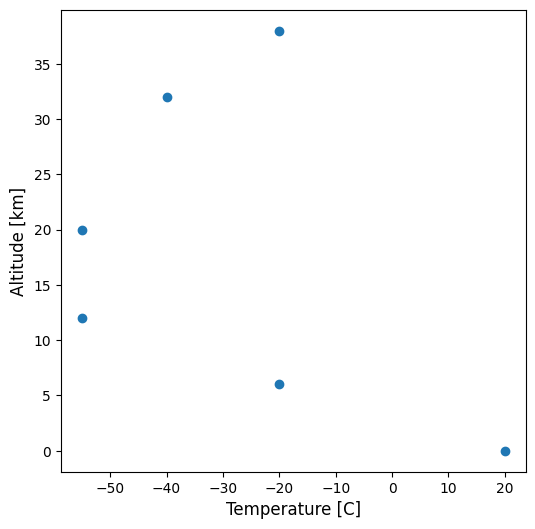

In [2]:

temperature = [ 20, -20, -55, -55, -40, -20  ]  #C
altitude    = [ 0,    6,  12,  20,  32,  38  ]  #km 

#giving this profile:
plt.figure( figsize = (6, 6) )
plt.plot( temperature, altitude, marker = 'o', linestyle = 'none')
plt.xlabel('Temperature [C]', fontsize = 12)
dm = plt.ylabel('Altitude [km]', fontsize = 12)

### Is this a "lost" campaign, or can we use the existing data to define the TP profile of the Earth?

### What if detectors mulfunctioned and we had only these points?

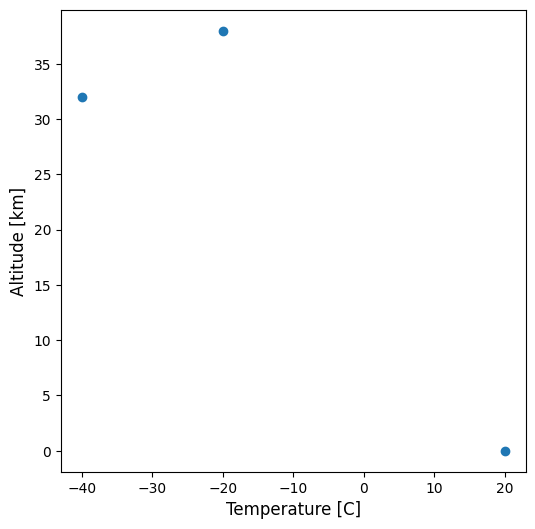

In [3]:
temperature = [ 20,  -40, -20  ]  #C
altitude    = [ 0,    32,  38  ]  #km 

plt.figure( figsize = (6, 6) )
plt.plot( temperature, altitude, marker = 'o', linestyle = 'none')
plt.xlabel('Temperature [C]', fontsize = 12)
dm = plt.ylabel('Altitude [km]', fontsize = 12)

### In some cases missing data or wanting to figure out what happens in between points is doable

### Assume following dataset (that follow some physical law) is there a way to figure out what happens between these two points? There's a lot of empty space between the two ...but, what would you guess the value of y for:
- p3 with x = 5 would be?
- p4  with x = 7 would be?

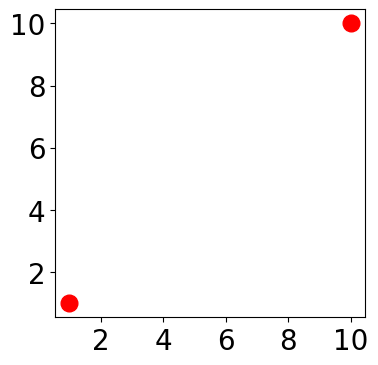

In [4]:
p1 = [1, 1]
p2 = [10, 10]

plt.figure( figsize = ( 4, 4 ) )
plt.plot( p1[ 0 ], p1[ 1 ], marker ='o', markersize = 12 , color = 'red')
plt.plot( p2[ 0 ], p2[ 1 ], marker ='o', markersize = 12 , color = 'red')
plt.xticks(fontsize = 20 )
dm = plt.yticks(fontsize = 20 )

### I assume your gut feeling was right. But, how do you figure this out in a mathematically consistent way? 

## **INTERPOLATION**

### If you have a function $f=f(x)$, interpolation is the process of using known values $f(x_0),f(x_1),f(x_2),...,f(x_N)$  to find values for $f(x)$ at points $x_i\in(x_1,n_N)$ with $x_i$ != $x_1, x_2,...,x_N$ . 

- In general, you need to find a function $L(x)$ called the interpolant which agrees with $f$ at the known points and which you use to compute the desired values

    - the example here is an obvious $f(x) = x \rightarrow y = x$  but we can solve it in the generic way:
    
        - we assume the simplest case of a linear interpolation (also because of known points) of the form $y = \alpha * (x-x_0) + \beta$  
        - the slope $\alpha$ between two points $(x_1,y_1)$ and $(x_2, y_2)$ is  $ \alpha = \frac{y_2-y_1}{x_2 -x_1}$ 
        - our $\beta$ will be defined from the point we want our line to start at, so here we can use $(x_1 , y_1)$ so that $y_1 = \alpha * (x_1 - x_1) + \beta \rightarrow \beta = y_1 $
        - this makes our equation: $$ y_j = \frac{y_2-y_1}{x_2 -x_1} * (x_j-x_1) + y_1$$
        

In [ ]:
#find a and b based on your two points:
alpha = ( p2[ 1 ] - p1[ 1 ] ) / ( p2[ 0 ] - p1[ 0 ] )
beta = p1[ 1 ]


#calculate y for x = 5 and x = 7:

print('Linear interpolation between p1 and p2 at point x = 5 gives:', alpha * ( 5 - p1[ 0 ] ) + beta, '\n' )
print('Linear interpolation between p1 and p2 at point x = 7 gives:', alpha * ( 7 - p1[ 0 ] ) + beta )


Linear interpolation between p1 and p2 at point x = 5 gives: 5.0 

Linear interpolation between p1 and p2 at point x = 7 gives: 7.0


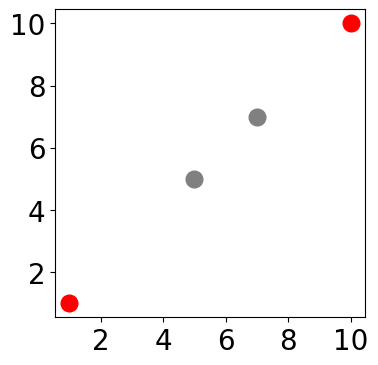

In [6]:
p3 = [ 5, 5 ]
p4 = [ 7, 7 ]

plt.figure( figsize = ( 4, 4 ) )

plt.plot( p1[ 0 ], p1[ 1 ], marker ='o', markersize = 12, color = 'red')
plt.plot( p3[ 0 ], p3[ 1 ], marker ='o', markersize = 12, color = 'gray')
plt.plot( p4[ 0 ], p4[ 1 ], marker ='o', markersize = 12, color = 'gray')
plt.plot( p2[ 0 ], p2[ 1 ], marker ='o', markersize = 12, color = 'red')
plt.xticks(fontsize = 20 )
dm = plt.yticks(fontsize = 20 )

### Let's try a bit more complex problem. You have the following observations:

In [7]:
x = np.array( [ 0, 5, 9 , 11, 14 ] )
y = np.array( [ -0.5, 109.5, 197.5, 241.5, 307.5 ] )

### Can you figure out the value of y at the following values?


In [8]:
x1 = np.array( [ 2 , 4, 8 , 12.5 ] )

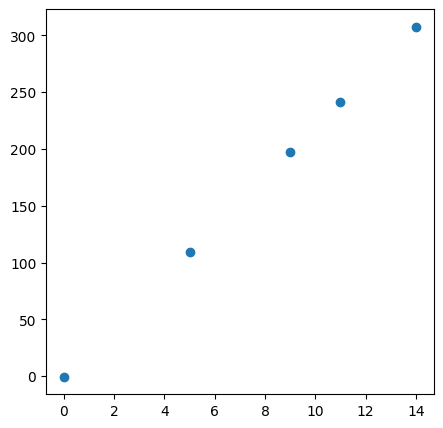

In [9]:
#step 101: let's visualize the data first:

plt.figure( figsize = ( 5 , 5 ) )
dm = plt.plot( x, y, marker = 'o', linestyle = 'none' )

In [10]:
# Linear interpolation seems a good choice, but is the slope constant?
#Let's test it:
for i in range(4):
    a = ( y[i+1] - y [i] ) / ( x[i+1] - x[i])
    print(a)

#---> constant slope; seems promising...Let's put it in action:


22.0
22.0
22.0
22.0


In [11]:
#do it the hard way:
for i in range( 4 ): # we have 4 points we want to study
    for j in range(1, 5 ): #and 5 points we may fall in-between
        if ( x[ j-1 ] <= x1[ i ] ) & ( x[ j ] >= x1[ i ] ):
            #get the slope between the 2 points:
            a = ( y[ j ] - y [ j-1 ] ) / ( x[ j ] - x[ j-1 ] )
            #use the lower left point as ancor:
            cx = x[ j-1 ]
            cy = y[ j-1 ]
            print( x1[ i ],  a * ( x1[ i ] - cx )  + cy )


2.0 43.5
4.0 87.5
8.0 175.5
12.5 274.5


### Numpy makes this messy code obsolete with its [interpolation function](https://numpy.org/doc/stable/reference/generated/numpy.interp.html)

In [12]:
y2 = np.interp( x1, x, y )

print( y2 )

[ 43.5  87.5 175.5 274.5]


### by definition, linear interpolation assumes that your data have linear trend with x; what happens when your data are not a linear function though?

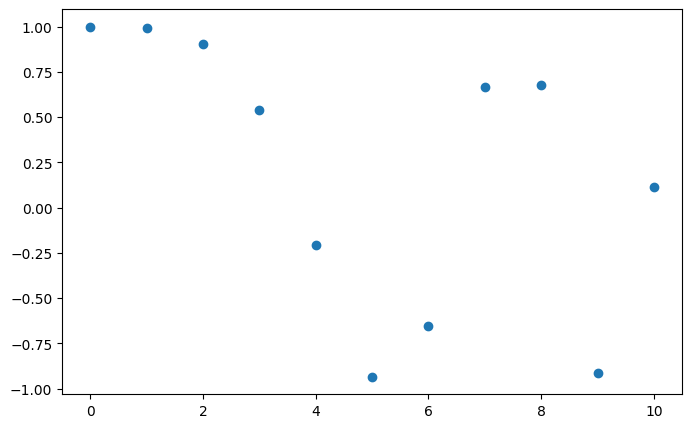

In [13]:
#let's see this example from https://docs.scipy.org/doc/scipy/reference/tutorial/interpolate.html
xcos = np.linspace( 0, 10, num = 11 )
ycos = np.cos( - xcos**2 / 9.0 )

#Let's plot it to see how it looks:
plt.figure( figsize = ( 8, 5 ) )
dm = plt.plot( xcos, ycos, 'o', linestyle = ' ' )

### you know that the underlying function is a $\cos x$
- would linear interpolation work?
    - if you just linearly connect the points you have they are a weird, sharp at points functions....so clearly, a linear interpolation between the two (numpy's linear interpolation) would not do a good job...
    
- is there a case on which linear interpolation could kinda work?

In [14]:
#try linear interp on locations :
xtry_lin = np.array( [ 3.5, 4.4, 7.6 ] )

ytry_lin = np.interp( xtry_lin, xcos, ycos )

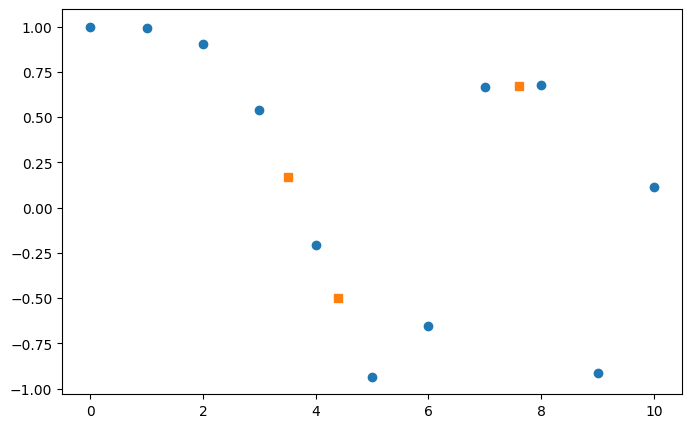

In [15]:
#Let's plot it to see how it looks:
plt.figure( figsize = ( 8, 5 ) )
plt.plot( xcos, ycos, 'o', linestyle = ' ' )
dm = plt.plot( xtry_lin, ytry_lin, 's', linestyle = '')

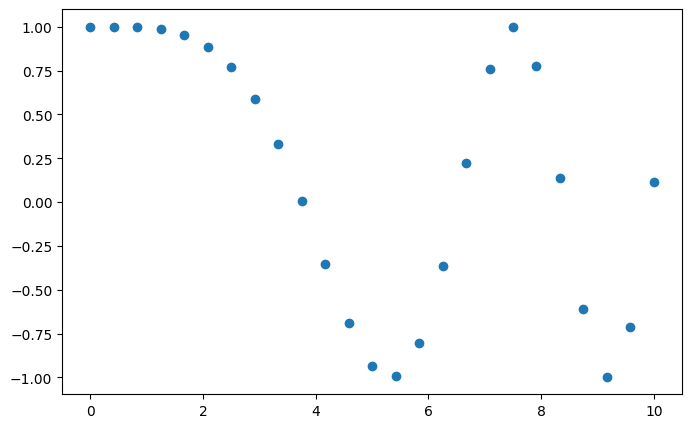

In [16]:
#check this version where we have denser observations:
xcos_b = np.linspace( 0, 10, num = 25 )
ycos_b = np.cos( - xcos_b**2 / 9.0 )
#Let's plot it to see how it looks:
plt.figure( figsize = ( 8, 5 ) )
dm = plt.plot( xcos_b, ycos_b, 'o', linestyle = ' ' )


In [17]:
#try again the linear interp on locations xtry_lin 

ytry_lin_b = np.interp( xtry_lin, xcos_b, ycos_b )

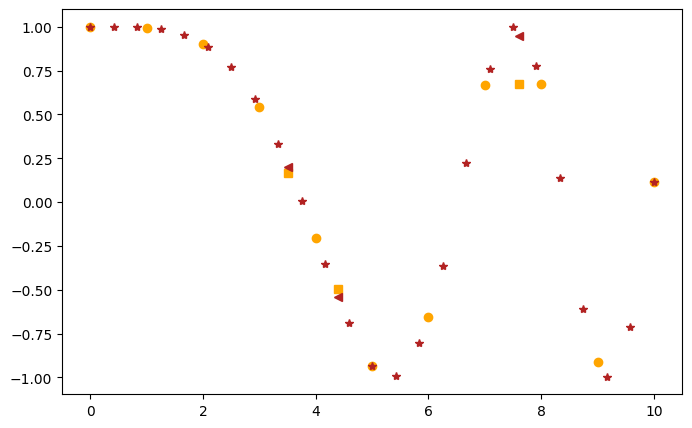

In [18]:
#Let's plot it to see how it looks:
plt.figure( figsize = ( 8, 5 ) )
plt.plot( xcos, ycos, 'o', linestyle = ' ', color='orange' )
plt.plot( xcos_b, ycos_b, '*', linestyle = ' ',color = 'firebrick' )
plt.plot( xtry_lin, ytry_lin, 's', linestyle = '', color = 'orange')
dm = plt.plot( xtry_lin, ytry_lin_b, '<', linestyle = '', color = 'firebrick')

- see the difference?
    - even if func is non linear we *could* get a decent approximation by linear interpolation some time if we have enough observations
    - often hard/impractical though, need *too* fine spaced observations
    
    - in comes scipy!

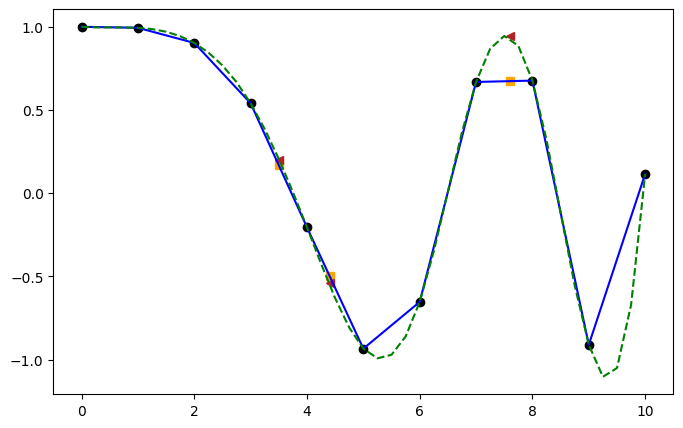

In [19]:
#compare linear with cubic spline interp:
f  = interp1d( xcos, ycos)                    # linear interpolation
f2 = interp1d( xcos, ycos, kind = 'cubic' )   # cubic spline interpolation

#make a new x array to use for plotting the cub splin interp:
xnew = np.linspace( 0, 10, num = 41)

plt.figure( figsize = ( 8, 5 ) )
#initial sparce observations:
plt.plot( xcos, ycos, 'o', linestyle = ' ', color='black' )
#our original linear interp with numpy:
plt.plot( xtry_lin, ytry_lin, 's', linestyle = '', color = 'orange')

#our 2nd interp when we had more observations:
plt.plot( xtry_lin, ytry_lin_b, '<', linestyle = '', color = 'firebrick')

#the linear interp with scipy:
plt.plot( xnew, f(xnew), 'b-') 

#and lastly, the cubic spline interp of scipy
dm = plt.plot(xnew, f2(xnew), 'g--')




- note that the cubic interp is done on the scarce dataset, not the more sense one
- still, it gives us a correct fit to the underlying law

### A bit more info on the interp1d [cubic spline interpolation ](https://docs.scipy.org/doc/scipy/tutorial/interpolate.html) 
- you can get an idea of the source code and idea behind cubic spline from [Numerical Recipes](http://phys.uri.edu/nigh/NumRec/bookfpdf/f3-3.pdf)
    - splines are "a polynomial between each pair of table points, but one whose coefficients are determined 'slightly' nonlocally. The nonlocality is designed to guarantee global smoothness in the interpolated function up to some order of derivative"  (Numerical Recipes FORTRAN 77)
    - A cubic spline is programmed to find the cubic polynomial $(a+ b*x + c*x^2 + d * x^3)$ within each interval (between your data points) that matches your data, and has continuous first and second derivatives at the knots 
    
- can also access functions directly




In [ ]:
#from scipy.interpolate import  splrep,splev

In [20]:
#create your x and y arrays:
xt = np.arange( 0, 2 * np.pi + np.pi / 4, 2 * np.pi / 8 )
yt = np.sin( xt )

#evaluate the spline derivatives (splrep) and the spline function  itself (splev):   ( FORTRAN powered :) )
tck = splrep( xt, yt, s = 0 )
xnew = np.arange( 0, 2 * np.pi, np.pi / 50 )
ynew = splev( xnew, tck, der = 0 )


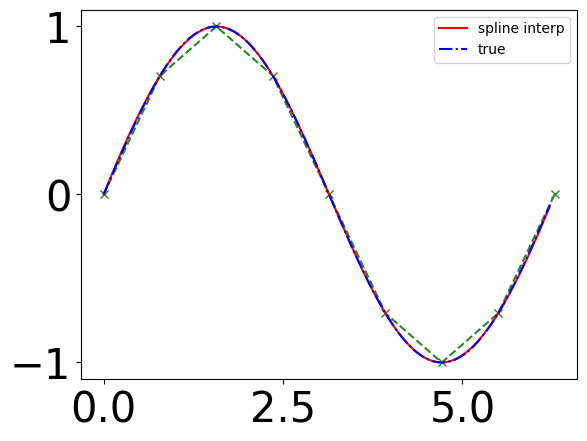

In [21]:
plt.plot( xt, yt, 'x',color = 'forestgreen', linestyle = '--')
plt.plot( xnew, ynew, color='red', label='spline interp')
plt.plot( xnew, np.sin(xnew), linestyle = '-.',color='blue', label = 'true')

plt.tick_params(axis='both', which='major', labelsize = 30 )
dm = plt.legend()

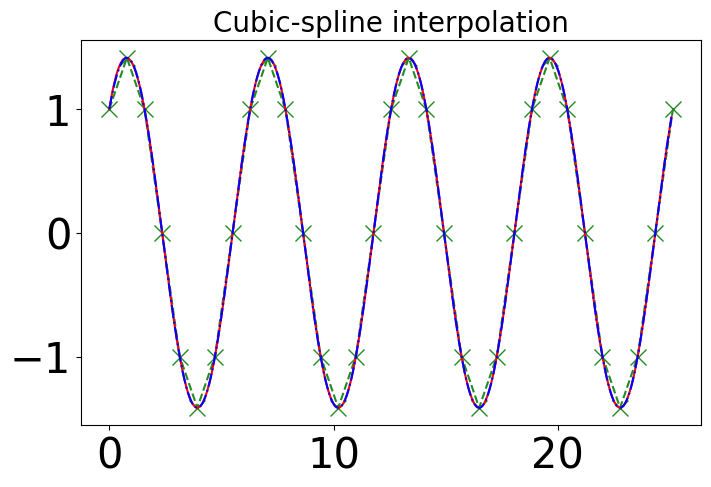

In [22]:
#try with a different dataset:

xt2 = np.arange(0, 8*np.pi+np.pi/4, 2*np.pi/8)
yt2 = np.sin(xt2)+np.cos(xt2)


#evaluate the spline derivatives (splrep) and the spline function (splev):   
tck2 = splrep(xt2, yt2, s=0)
xnew2 = np.arange(0, 8*np.pi, np.pi/50)
ynew2 = splev(xnew2, tck2, der=0)

plt.figure( figsize = (8 , 5) )

plt.plot(xt2, yt2, 'x',color='forestgreen',linestyle='--',markersize=12)
plt.plot(xnew2, ynew2, color='red')
plt.plot(xnew2, np.sin(xnew2) +np.cos(xnew2), linestyle = '-.',color='blue')

plt.title('Cubic-spline interpolation',fontsize = 20)

plt.tick_params(axis='both', which='major', labelsize=30)



### What if you have a 2D array and you want to interpolate between points in 2 dimensions? Then we have the bilinear interpolation:


In [ ]:
#from scipy.interpolate import  interp2d

In [23]:
#let's make our dataset:

x = np.arange( -5.01, 5.01, 0.25 )
y = np.arange( -5.01, 5.01, 0.25 )
xx, yy = np.meshgrid( x, y )

#Create a 2D array that uses xx , yy
z = np.sin( xx**2 + yy**2 ) / ( xx**2 + yy**2 )


In [29]:
# use the 2D interpolation
from scipy.interpolate import RegularGridInterpolator
# f = interp2d(x, y, z, kind='cubic')
f = RegularGridInterpolator(x, y, z) # kind='cubic')

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [25]:
# plot the result:
xnew = np.arange( -5.01, 5.01, 1e-2 )
ynew = np.arange( -5.01, 5.01, 1e-2 )
znew = f( xnew, ynew )

plt.figure( figsize = ( 12, 8) )

plt.plot(x, z[0, :], 'ro')
plt.plot(xnew, znew[0, :], 'b-')
plt.xticks(fontsize =20 )
dm = plt.yticks(fontsize =20 )


TypeError: _Interpolator1D.__call__() takes 2 positional arguments but 3 were given

In [30]:
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.griddata.html
#Suppose we want to interpolate the 2-D function on a grid in [0, 1]x[0, 1]

def func(x, y):
     return x*(1-x)*np.cos(4*np.pi*x) * np.sin(4*np.pi*y**2)**2


grid_x, grid_y = np.mgrid[0:1:100j, 0:1:200j]

#but we only know its values at 1000 data points:


points = np.random.rand( 1000, 2 )
values = func( points[ :, 0 ], points[ :, 1 ] )
#This can be done with griddata() – below we try out all of the interpolation methods:


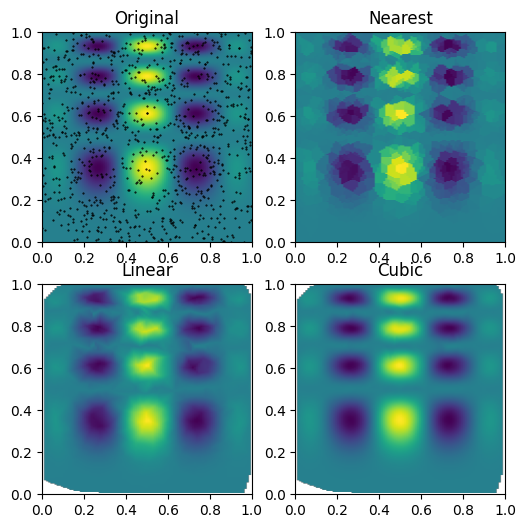

In [31]:
from scipy.interpolate import griddata

grid_z0 = griddata(points, values, (grid_x, grid_y), method='nearest')
grid_z1 = griddata(points, values, (grid_x, grid_y), method='linear')
grid_z2 = griddata(points, values, (grid_x, grid_y), method='cubic')

#One can see that the exact result is reproduced by all of the methods to some degree, but for this 
#smooth function the piecewise cubic interpolant gives the best results:


plt.subplot(221)
plt.imshow(func(grid_x, grid_y).T, extent=(0,1,0,1), origin='lower')
plt.plot(points[:,0], points[:,1], 'k.', ms=1)
plt.title('Original')

plt.subplot(222)
plt.imshow(grid_z0.T, extent=(0,1,0,1), origin='lower')
plt.title('Nearest')

plt.subplot(223)
plt.imshow(grid_z1.T, extent=(0,1,0,1), origin='lower')
plt.title('Linear')

plt.subplot(224)
plt.imshow(grid_z2.T, extent=(0,1,0,1), origin='lower')
plt.title('Cubic')
plt.gcf().set_size_inches(6, 6)


In [ ]:
#remember though, that for images astropy is to be prefered to numpy or scipy

### Intermezzo <br> Extrapolation: 

- estimate the value of a function y(x) outside the initial range [x1,x2] for which we have data
- most basic version: linear extrapolation
- create a tangent line at the end of the known data and extend it beyond that limit

<img src="extrapolation_example.png" width=700 height=400 />

- for simple linear data (y = ax+b) works fine
- for more complex data it can be OK(ihs) when you want a point not too far beyond the known data

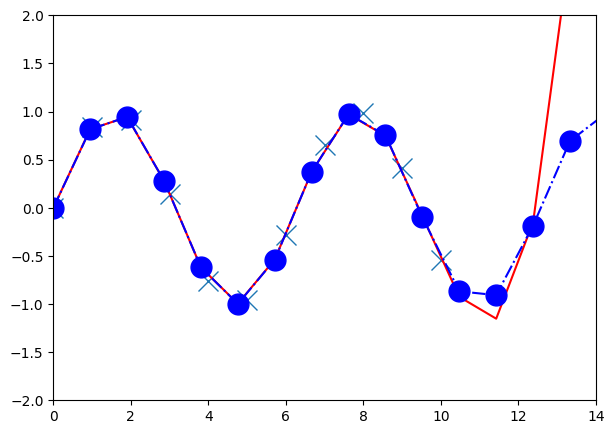

In [32]:
x = np.linspace(0, 10, 11)
y = np.sin(x)
x2 = np.linspace(0, 20, 22)
y2 = np.sin( x2 )
tck = splrep(x, y, s = 0 )
xnew = x2 
ynew = splev(xnew, tck, der =0)

fig, ax = plt.subplots(figsize = ( 7, 5 ) )

plt.plot( x, y, 'x',linestyle = 'none',markersize = 15)
plt.plot( xnew, ynew, color='red')
plt.plot( xnew, np.sin(xnew), linestyle = '-.',color='blue',marker='o',markersize = 15)
plt.xlim(0,14)
dm = plt.ylim(-2,2)

#notice how it deviates a lot, very fast

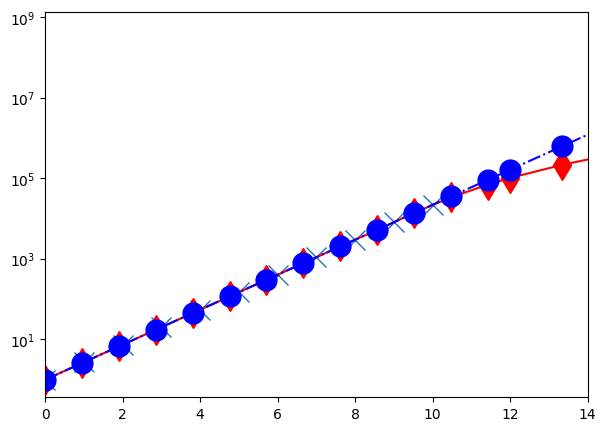

In [33]:
#or try:
x = np.linspace( 0, 10, 11, endpoint=True)
y = np.exp( x )

x2[13] = 12.0

tck = splrep( x, y, s = 0 )
xnew = x2 
ynew = splev(xnew, tck, der=0)

fig, ax = plt.subplots(figsize = ( 7 , 5 ) )
#semilogy asks the plot to be logarithmic scale on the y axis (also have semilogx; loglog....)
plt.semilogy( x, y, 'x',linestyle = 'none',markersize = 15)
plt.semilogy( xnew, ynew, color='red', marker='d',markersize = 15)
plt.semilogy( xnew, np.exp(xnew), linestyle = '-.',color='blue',marker='o',markersize = 15)
dm = plt.xlim(0,14)


## Correlations


- When looking at a scatter plot you may find that the x and y parameters are correlated, anti-correlated or not correlated. What does that tell you?

<img src="betterplot8.png" width=750 height=550 />

[Source](https://infogram.com/blog/scatter-plots/)

- careful, though, as sometimes this can be a slippery slope

<img src="correlation_causation2.png" width=750 height=550 />


<img src="correlation_causation_xkcd.png" width=550 height=350 /> ([xckd](https://xkcd.com/552/))



- rule of thumb: 2 functions are correlated if the sum of the product of their value changes is positive (i.e., if one goes negative so does the other; if one goes positive so does the other)

- correlation is connected to covariance ($\frac{\mathrm{cov}(x,y)}{\sigma_x\sigma_y}$)

- measure of correlation: correlation coefficient (most often [Pearson's r](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html) ) $\in[-1,1]$

- can you name an example of variables $y,x$ that are perfectly correlated/anticorrelated?

In [ ]:
#test an example of the r-test on different samples
x  = np.linspace(0,2*np.pi, 100)
t1 = np.sin( 2*x )
t2 = np.cos(.5*np.pi+ 2*x )

In [ ]:
#from scipy import stats

In [ ]:
testr1 = stats.pearsonr(t1, t2)

In [ ]:
#another test case:
t3 = np.cos( .25*np.pi+ 2*x )

In [ ]:
testr2 = stats.pearsonr( t1, t3 )

In [ ]:
#last one:
t4 = np.cos( .75*np.pi+ 2*x )
testr3 = stats.pearsonr( t2, t4 )

In [ ]:
#lets plot the pairs we compared, what do you guess the r will be?

fig,ax = plt.subplots( 1, 3, figsize = ( 20, 6 )  )

ax[0].plot( x, t1, 'b' )
ax[0].plot( x, t2, 'g' )

ax[1].plot( x, t1, 'b' )
ax[1].plot( x, t3, 'g' )

ax[2].plot( x, t2, 'b' )
dm = ax[2].plot( x, t4, 'g' )

In [ ]:
print(testr1)
#data are perfectly anticorrelated r = -1, p = 0

print( testr2)
#strong anticorrelation

print( testr3)
#strong correlation 

In [ ]:
#what about this test case?
t4 =  np.random.rand(100)

In [ ]:
plt.plot(x,t1)
plt.plot(x,t4)

In [ ]:
testr4 = stats.pearsonr( t1, t4 )
print(testr4)
#nearly uncorrelated data

In [ ]:
y1 =  2 * x
y2 = -2 * x

print( stats.pearsonr( x, y1 ), stats.pearsonr( x, y2 ) )

### Parameter error estimation 


- when you fit data (linfit, curvefit etc) you get your best fit parameters but, also, a covariance matrix. For f(x,y) the covariance matrix is of the form:
|    |    | 
|:-----:|:---:|
| $\frac{\partial f^2}{\partial x^2}$ |  $\frac{\partial f^2}{\partial x \partial y}$ |
| $\frac{\partial f^2}{\partial y \partial x}$ |  $\frac{\partial y^2}{\partial y^2}$ | 

- connected to correlation (see eq. earlier)

- connected to parameter $\sigma$s:
|    |    | 
|:-----:|:---:|
| $\sigma_x^2$ |  $\sigma_{xy}$ |
| $\sigma_{yx}$ |  $\sigma_y^2$ | 

    - where $\sigma_{x,y}^2$ are the uncertainty of $x,y$ and $\sigma_{yx,xy}$ their correlations
    
- can use them to constrain how precise your fit is
